# Tutorial — LGD (regressão com alvo em [0,1] bimodal)

A **LGD** (*Loss Given Default*) é uma variável de risco **contínua entre 0 e 1** com uma
característica peculiar: forte **concentração nos extremos** — muitos contratos com perda ~0
(cura/recuperação total) e muitos com perda ~1 (perda total). A massa no meio é menor.

Este tutorial mostra a esteira `yggdrasil` aplicada a esse caso (`problem_type="regression"`):
métricas de erro (RMSE, MAE, MAPE…), ratings, PSI, SHAP e relatórios — o mesmo fluxo do
tutorial de PD, mas com alvo contínuo.

> Compare com o tutorial de classificação: `notebooks/tutoriais/00_tutorial_yggdrasil.ipynb`.

## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
RANDOM_STATE = 42

## 1. Gerando uma LGD sintética (bimodal em 0 e 1)

Construímos a LGD a partir de uma *propensão de perda* derivada das features (para haver sinal),
com uma componente Beta contínua e **inflação dos extremos**: baixa propensão → muitos zeros
(cura), alta propensão → muitos uns (perda total).

In [2]:
from sklearn.datasets import make_regression

n = 4000
X, lat = make_regression(n_samples=n, n_features=7, n_informative=5,
                         noise=8.0, random_state=RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

# Propensão de perda (0..1) a partir do latente.
prop = 1.0 / (1.0 + np.exp(-(lat - lat.mean()) / (lat.std() + 1e-9)))

# Componente contínua (Beta) correlacionada com a propensão.
lgd = rng.beta(0.6 + 4.0 * prop, 0.6 + 4.0 * (1.0 - prop))

# Inflação dos extremos: cura (0) quando propensão baixa, perda total (1) quando alta.
u = rng.random(n)
lgd = np.where(u < 0.25 * (1.0 - prop), 0.0, lgd)
lgd = np.where(u > 1.0 - 0.25 * prop, 1.0, lgd)
lgd = np.clip(lgd, 0.0, 1.0)

meses = pd.date_range("2023-01-01", periods=12, freq="MS")
df = pd.DataFrame(X, columns=[f"feat_{i:02d}" for i in range(7)])
df["target"] = lgd
df["dt_ref"] = rng.choice(meses, size=n)
df["amostra"] = np.where(df["dt_ref"] >= meses[8], "OOT", "DES")
df.loc[df.sample(frac=0.05, random_state=1).index, "amostra"] = "SIMUL"

frac0 = (df["target"] <= 0.001).mean()
frac1 = (df["target"] >= 0.999).mean()
print(f"% LGD ~ 0 (cura): {frac0:.1%}  |  % LGD ~ 1 (perda total): {frac1:.1%}")

% LGD ~ 0 (cura): 12.7%  |  % LGD ~ 1 (perda total): 12.9%


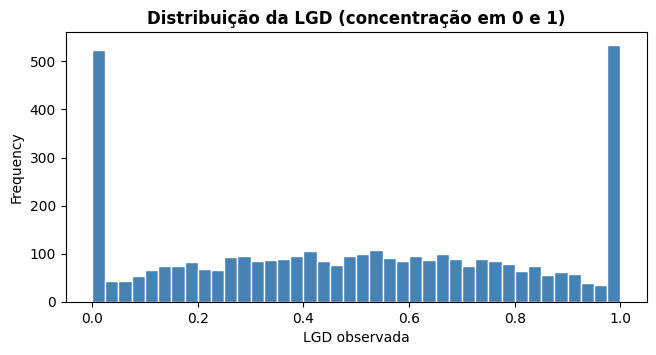

In [3]:
# A marca registrada da LGD: distribuição bimodal com massa em 0 e 1.
fig_h, ax = plt.subplots(figsize=(7.5, 3.5))
df["target"].plot(kind="hist", bins=40, color="steelblue", edgecolor="white", ax=ax)
ax.set_title("Distribuição da LGD (concentração em 0 e 1)", fontweight="bold")
ax.set_xlabel("LGD observada")
plt.show()

## 2. `ColumnConfig`

Mesmo contrato de colunas do tutorial de PD — muda apenas que o `target` é contínuo.

In [4]:
from yggdrasil import ColumnConfig
from yggdrasil.data import analysis_samples_present, scoring_only_samples_present

cfg = ColumnConfig()
print("Features:", cfg.feature_columns(df))
print("Amostras de análise:", analysis_samples_present(df, cfg))
print("Scoring-only       :", scoring_only_samples_present(df, cfg))

Features: ['feat_00', 'feat_01', 'feat_02', 'feat_03', 'feat_04', 'feat_05', 'feat_06']
Amostras de análise: ['DES', 'OOT']
Scoring-only       : ['SIMUL']


## 3. Treinar um modelo de regressão

Usamos um `RandomForestRegressor` treinado no DES. O **score** aqui é a própria LGD prevista
(contínua), não uma probabilidade.

In [5]:
from sklearn.ensemble import RandomForestRegressor

feats = cfg.feature_columns(df)
treino = df[df["amostra"] == cfg.dev_sample]

model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
model.fit(treino[feats], treino["target"])

df[cfg.score_col] = np.clip(model.predict(df[feats]), 0.0, 1.0)
dev = df[df["amostra"] == cfg.dev_sample]
oot = df[df["amostra"] == cfg.oot_sample]
df[["amostra", "target", cfg.score_col]].head()

,amostra,target,prediction
0,DES,0.0000,0.1937
1,OOT,0.0000,0.7211
2,DES,0.7436,0.6886
3,DES,0.2755,0.3209
4,DES,0.7743,0.6776


## 4. Métricas de regressão e *shifts*

Para regressão a esteira calcula **RMSE, MAE, MAPE (robusto), sMAPE, R², viés médio e MedAE**.
O MAPE é robusto: ignora alvos ≈ 0 (frequentes na LGD) que estourariam a divisão.

In [6]:
from yggdrasil.metrics import metric_by_sample, sample_shifts

df_analise = df[df["amostra"].isin(cfg.analysis_samples)]
met = metric_by_sample(df_analise, cfg, "regression")
print("Métricas por amostra:")
display(pd.DataFrame(met).T)
print("Shifts DES -> OOT:")
display(pd.Series(sample_shifts(met, cfg), name="shift").to_frame())

Métricas por amostra:


,rmse,mae,mape,smape,medae,r2,mean_bias
DES,0.1077,0.0856,23.9655,41.7423,0.0725,0.8945,-0.0003
OOT,0.2907,0.2348,62.3412,62.5826,0.2068,0.2299,-0.0110


Shifts DES -> OOT:


,shift
rmse_shift_abs,0.1830
rmse_shift_rel,1.6984
mae_shift_abs,0.1492
mae_shift_rel,1.7433
mape_shift_abs,38.3757
mape_shift_rel,1.6013
smape_shift_abs,20.8402
smape_shift_rel,0.4993
medae_shift_abs,0.1343
medae_shift_rel,1.8527


## 5. Grupos homogêneos (ratings de LGD)

As mesmas 4 metodologias agrupam a **LGD prevista** em faixas ordenadas. A fusão monotônica
(quantil/árvore) usa o teste de **Mann-Whitney** no OOT (alvo contínuo).

In [7]:
from yggdrasil.ratings import build_ratings

rating_cols = []
for strat in build_ratings(["decis", "quantil", "arvore", "optbin"]):
    df[strat.column] = strat.fit_transform(df, cfg, "regression")
    rating_cols.append(strat.column)
    print(f"{strat.name:8s} -> {len(strat.labels_)} grupos: {strat.labels_}")

df_analise = df[df["amostra"].isin(cfg.analysis_samples)].copy()
print("LGD média observada por decil (DES):")
display(
    df[df["amostra"] == "DES"].groupby("rating_decis")["target"].mean().to_frame("lgd_media")
)

decis    -> 10 grupos: ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10']
quantil  -> 16 grupos: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P']
arvore   -> 9 grupos: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


optbin   -> 10 grupos: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
LGD média observada por decil (DES):


,lgd_media
rating_decis,
R01,0.0235
R02,0.0732
R03,0.1975
R04,0.3328
R05,0.4470
R06,0.5400
R07,0.6544
R08,0.7855
R09,0.9016


## 6. PSI — estabilidade no tempo

In [8]:
from yggdrasil.monitoring import psi, psi_summary, psi_rating_over_time, classify_psi

p = psi(dev[cfg.score_col], oot[cfg.score_col])
print(f"PSI da LGD prevista (DES->OOT): {p:.4f}  [{classify_psi(p)}]")
print("PSI agregado:")
display(pd.Series(psi_summary(df_analise, cfg, rating_cols), name="psi").to_frame())
print("PSI do decil ao longo das safras:")
display(psi_rating_over_time(df, "rating_decis", cfg))

PSI da LGD prevista (DES->OOT): 0.5219  [instavel]
PSI agregado:


,psi
psi_score_oot,0.5219
psi_rating_decis_oot,0.5219
psi_rating_quantil_oot,0.5353
psi_rating_arvore_oot,0.4568
psi_rating_optbin_oot,0.5599


PSI do decil ao longo das safras:


,mes,psi,n,flag
0,2023-01-01,0.0073,321,estavel
1,2023-02-01,0.0220,354,estavel
2,2023-03-01,0.0124,315,estavel
3,2023-04-01,0.0081,318,estavel
4,2023-05-01,0.0071,314,estavel
5,2023-06-01,0.0149,340,estavel
6,2023-07-01,0.0143,324,estavel
7,2023-08-01,0.0265,325,estavel
8,2023-09-01,0.3939,312,instavel
9,2023-10-01,0.6942,357,instavel


## 7. SHAP — interpretabilidade

In [9]:
from yggdrasil.interpretability import compute_shap, shap_feature_importance

shap_values, X_amostra = compute_shap(model, dev[feats], problem_type="regression",
                                      sample_size=1000)
display(shap_feature_importance(shap_values, feats))

,feature,mean_abs_shap
0,feat_03,0.0850
1,feat_02,0.0839
2,feat_04,0.0647
3,feat_01,0.0564
4,feat_00,0.0247
5,feat_05,0.0128
6,feat_06,0.0120


## 8. Relatório por grupo + dashboard

O `group_report` mostra a **LGD média prevista vs observada** por grupo, representatividade e
monotonicidade. O dashboard inclui a seção SHAP (importância + beeswarm) ao passar `model` + `X_shap`.

In [10]:
from yggdrasil.reporting import group_report, is_monotonic

rep = group_report(df_analise, "rating_decis", cfg, "regression")
print("Monotônico?", is_monotonic(rep))
display(rep)

Monotônico? True


,rating,volume,pct_volume,score_medio,target_medio,score_min,score_max,vol_DES,pct_DES,target_medio_DES,score_medio_DES,vol_OOT,pct_OOT,target_medio_OOT,score_medio_OOT
0,R01,271,7.1316,0.1146,0.0370,0.0341,0.1558,249,10.0040,0.0235,0.1130,22,1.6781,0.1894,0.1325
1,R02,340,8.9474,0.1956,0.1253,0.1564,0.2348,249,10.0040,0.0732,0.1943,91,6.9413,0.2679,0.1991
2,R03,392,10.3158,0.2766,0.2310,0.2350,0.3223,249,10.0040,0.1975,0.2754,143,10.9077,0.2893,0.2787
3,R04,422,11.1053,0.3630,0.3514,0.3223,0.4042,249,10.0040,0.3328,0.3635,173,13.1960,0.3783,0.3623
4,R05,464,12.2105,0.4492,0.4403,0.4048,0.4932,248,9.9638,0.4470,0.4488,216,16.4760,0.4327,0.4498
5,R06,454,11.9474,0.5319,0.5475,0.4935,0.5734,249,10.0040,0.5400,0.5328,205,15.6369,0.5565,0.5308
6,R07,490,12.8947,0.6214,0.6494,0.5738,0.6688,249,10.0040,0.6544,0.6202,241,18.3829,0.6441,0.6226
7,R08,395,10.3947,0.7113,0.7460,0.6692,0.7525,249,10.0040,0.7855,0.7122,146,11.1365,0.6786,0.7098
8,R09,309,8.1316,0.7914,0.8825,0.7526,0.8354,249,10.0040,0.9016,0.7928,60,4.5767,0.8035,0.7858
9,R10,263,6.9211,0.8819,0.9748,0.8356,0.9604,249,10.0040,0.9837,0.8832,14,1.0679,0.8154,0.8570


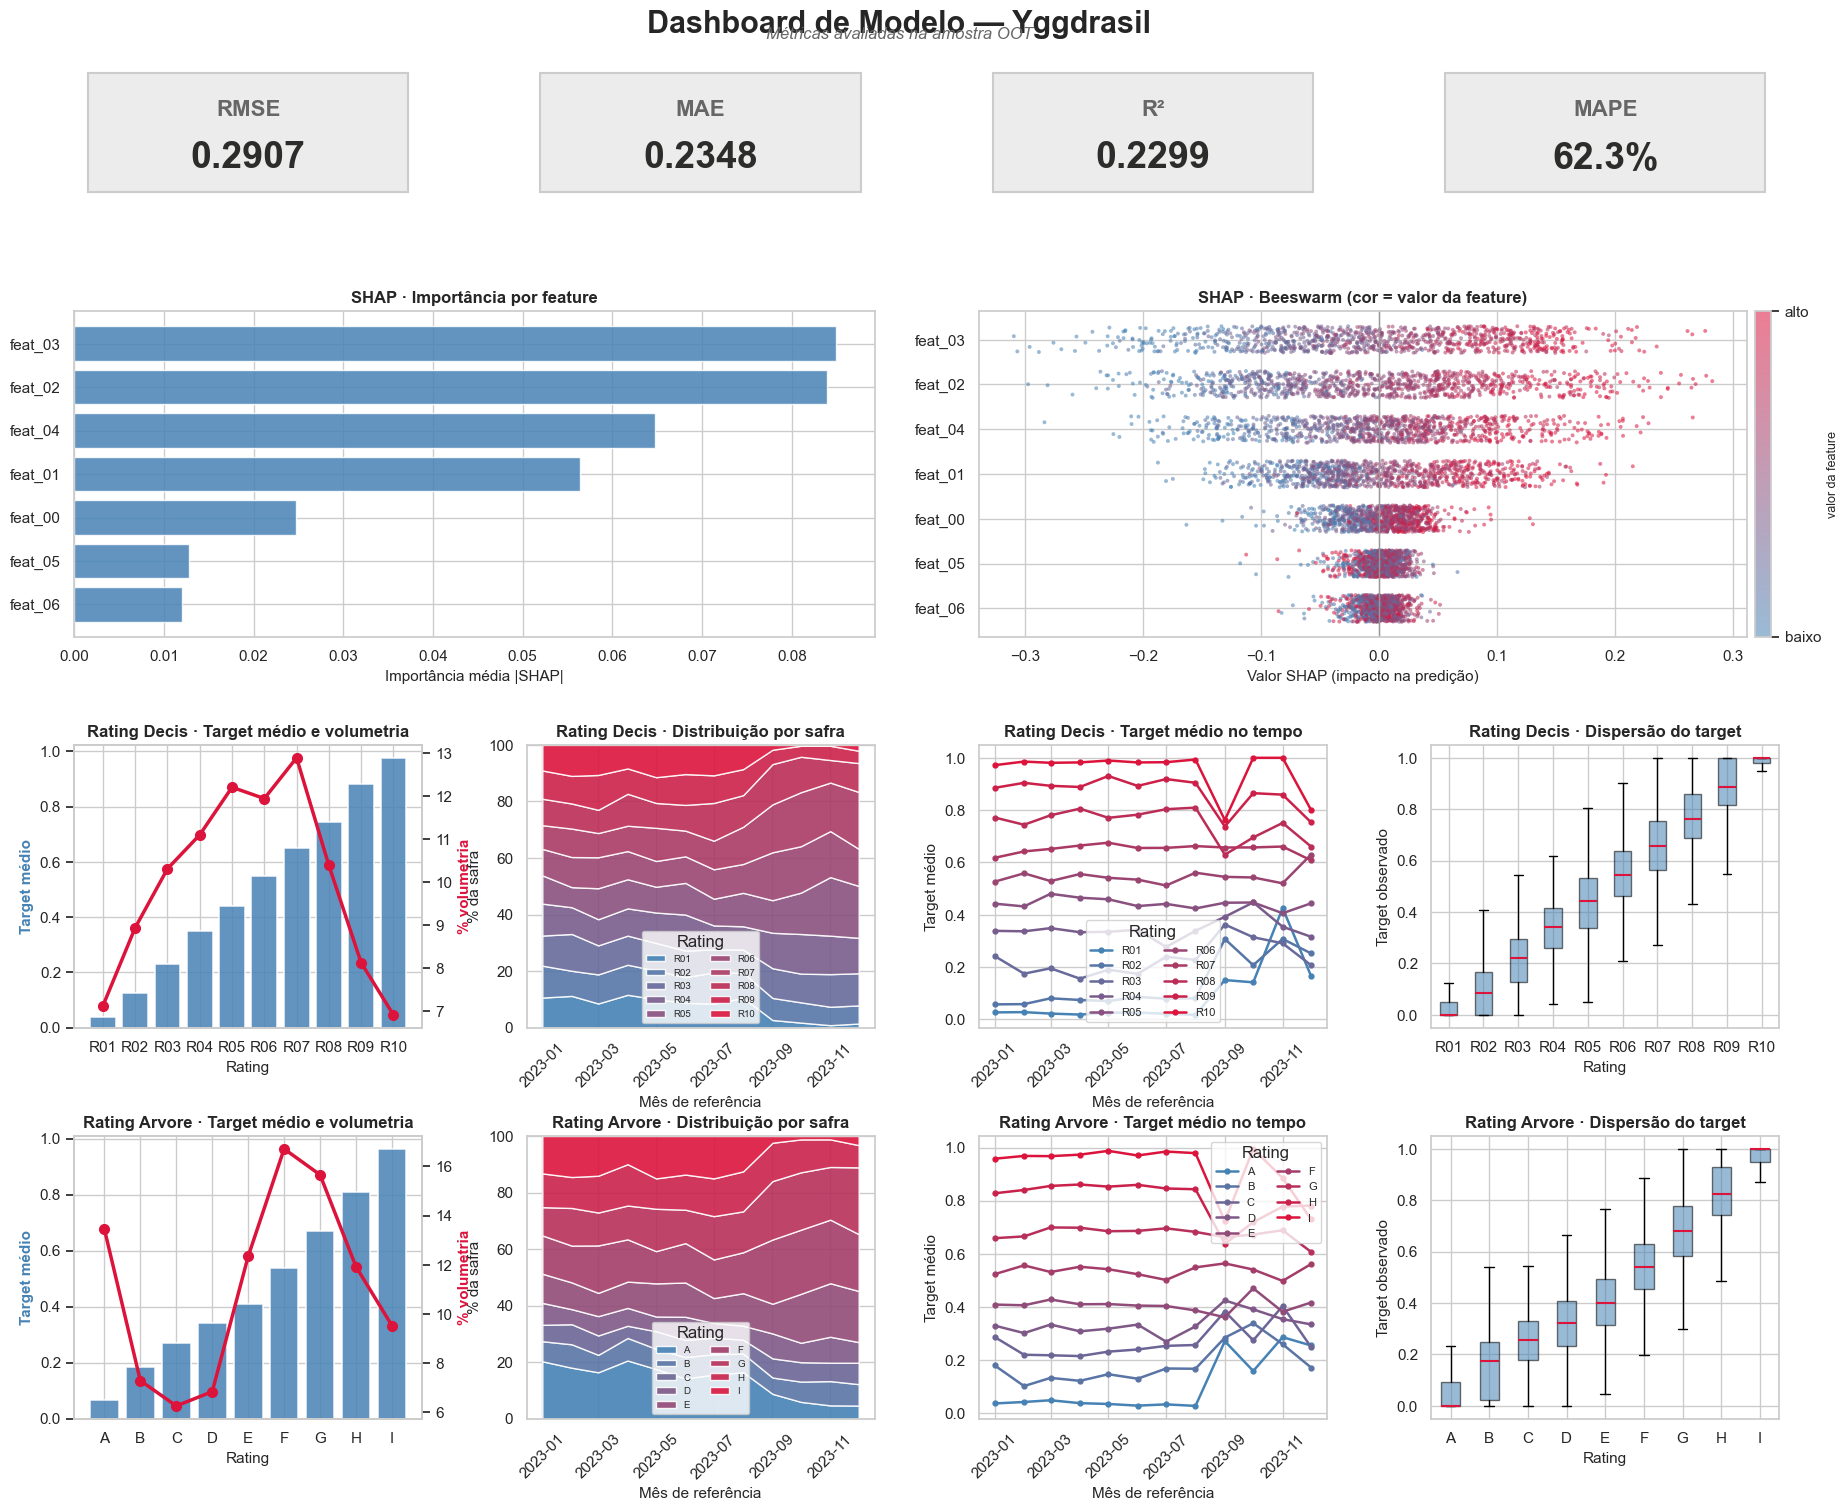

In [11]:
from yggdrasil.reporting import build_dashboard

fig = build_dashboard(df_analise, ["rating_decis", "rating_arvore"], cfg,
                      "regression", metrics=met.get("OOT", {}),
                      model=model, X_shap=dev[feats])
fig

## 9. Esteira completa com MLflow

In [12]:
import mlflow
from yggdrasil import MLPipeline

mlflow.set_tracking_uri("file:./mlruns")
pipe = MLPipeline(cfg, problem_type="regression",
                  ratings=["decis", "quantil", "arvore", "optbin"])
resultado = pipe.run(df, model=model, experiment="tutorial_lgd",
                     run_name="lgd", tags={"model_type": "LGD"})
print("run_id:", resultado.run_id)
display(pd.DataFrame(resultado.metrics_by_sample).T)

2026/06/14 18:11:55 INFO mlflow.tracking.fluent: Experiment with name 'tutorial_lgd' does not exist. Creating a new experiment.


2026/06/14 18:14:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/14 18:14:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


run_id: cc2600bc63814a148f3aae9fee2ea5a3


,rmse,mae,mape,smape,medae,r2,mean_bias
DES,0.1077,0.0856,23.9655,41.7423,0.0725,0.8945,-0.0003
OOT,0.2907,0.2348,62.3412,62.5826,0.2068,0.2299,-0.0110


## 10. Amostras *scoring-only* e MLflow

Como no PD, amostras fora de `analysis_samples` (ex.: `SIMUL`) recebem LGD prevista + rating, mas
ficam fora da análise. Veja os runs com `mlflow ui --backend-store-uri ./mlruns`.

In [13]:
print("Amostras com análise:", list(resultado.metrics_by_sample.keys()))
display(
    resultado.df_scored[resultado.df_scored["amostra"] == "SIMUL"]
    [["amostra", cfg.score_col] + resultado.rating_cols].head()
)

Amostras com análise: ['DES', 'OOT']


,amostra,prediction,rating_decis,rating_quantil,rating_arvore,rating_optbin
6,SIMUL,0.6435,R07,K,G,E
17,SIMUL,0.2534,R03,C,B,D
79,SIMUL,0.4998,R06,I,F,E
94,SIMUL,0.4778,R05,H,F,E
98,SIMUL,0.6421,R07,K,G,E
